In [1]:
# Banking dataset from Kaggle

In [2]:
'''
5 marks for coding
5 marks for presentation
5 marks for communication
5 marks for teamwork
'''

'\n5 marks for coding\n5 marks for presentation\n5 marks for communication\n5 marks for teamwork\n'

In [3]:
import pandas as pd

df = pd.read_csv(r'Dataset/Comprehensive_Banking_Database.csv')
df.head(2)

,Customer ID,First Name,Last Name,Age,Gender,Address,City,Contact Number,Email,Account Type,...,Minimum Payment Due,Payment Due Date,Last Credit Card Payment Date,Rewards Points,Feedback ID,Feedback Date,Feedback Type,Resolution Status,Resolution Date,Anomaly
0,1,Joshua,Hall,45,Male,Address_1,Fort Worth,19458794854,joshua.hall@kag.com,Current,...,226.22,11/26/2023,3/20/2023,8142,1,10/6/2023,Suggestion,Resolved,1/22/2023,1
1,2,Mark,Taylor,47,Female,Address_2,Louisville,19458794855,mark.taylor@kag.com,Current,...,42.84,11/5/2023,6/16/2023,4306,2,4/7/2023,Complaint,Resolved,8/27/2023,1


In [4]:
df.columns

Index(['Customer ID', 'First Name', 'Last Name', 'Age', 'Gender', 'Address',
       'City', 'Contact Number', 'Email', 'Account Type', 'Account Balance',
       'Date Of Account Opening', 'Last Transaction Date', 'TransactionID',
       'Transaction Date', 'Transaction Type', 'Transaction Amount',
       'Account Balance After Transaction', 'Branch ID', 'Loan ID',
       'Loan Amount', 'Loan Type', 'Interest Rate', 'Loan Term',
       'Approval/Rejection Date', 'Loan Status', 'CardID', 'Card Type',
       'Credit Limit', 'Credit Card Balance', 'Minimum Payment Due',
       'Payment Due Date', 'Last Credit Card Payment Date', 'Rewards Points',
       'Feedback ID', 'Feedback Date', 'Feedback Type', 'Resolution Status',
       'Resolution Date', 'Anomaly'],
      dtype='object')

In [6]:
cardTypes = df.groupby('Card Type').count()
cardTypes

,Customer ID,First Name,Last Name,Age,Gender,Address,City,Contact Number,Email,Account Type,...,Minimum Payment Due,Payment Due Date,Last Credit Card Payment Date,Rewards Points,Feedback ID,Feedback Date,Feedback Type,Resolution Status,Resolution Date,Anomaly
Card Type,,,,,,,,,,,,,,,,,,,,,
AMEX,1679,1679,1679,1679,1679,1679,1679,1679,1679,1679,...,1679,1679,1679,1679,1679,1679,1679,1679,1679,1679
MasterCard,1696,1696,1696,1696,1696,1696,1696,1696,1696,1696,...,1696,1696,1696,1696,1696,1696,1696,1696,1696,1696
Visa,1625,1625,1625,1625,1625,1625,1625,1625,1625,1625,...,1625,1625,1625,1625,1625,1625,1625,1625,1625,1625


In [12]:
df.head(2)['Transaction Date']

0    12/7/2023
1    4/27/2023
Name: Transaction Date, dtype: object

In [16]:
df.head(10)['Rewards Points']

0    8142
1    4306
2    4842
3    9463
4    2209
5     478
6    5745
7    5559
8    4432
9    8226
Name: Rewards Points, dtype: int64

In [20]:
transactionTypes = df.groupby('Transaction Type').count().index
transactionTypes

Index(['Deposit', 'Transfer', 'Withdrawal'], dtype='object', name='Transaction Type')

In [35]:
df.head(2)['Transaction Date']

0    12/7/2023
1    4/27/2023
Name: Transaction Date, dtype: object

In [27]:
pd.DataFrame(data = df, columns = ['Approval/Rejection Date', 'Loan Amount'])

,Approval/Rejection Date,Loan Amount
0,5/11/2021,32200.06
1,7/30/2020,47743.52
2,1/17/2021,47981.31
3,2/15/2022,4482.80
4,7/31/2020,1092.33
...,...,...
4995,6/10/2021,34684.98
4996,12/24/2020,45181.31
4997,3/6/2020,44660.01
4998,8/13/2021,35551.65


In [32]:
# print(pd.DataFrame.__doc__)

loanDates = list(map(lambda x : int(x[-4:]), pd.DataFrame(data = df, columns = ['Approval/Rejection Date', 'Loan Amount'])['Approval/Rejection Date']))
set(loanDates)

{2020, 2021, 2022}

In [42]:
transactDates = list(map(lambda x : int(x[: x.index('/')]), pd.DataFrame(data = df, columns = ['Transaction Date'][)['Transaction Date']))
set(transactDates)

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}

In [43]:
# transDates = list(df['Transaction Date'])

In [47]:
transactFrame = pd.DataFrame(data = df, columns = ['Transaction Date', 'Transaction Type', 'Transaction Amount'])
transactTypes = transactFrame['Transaction Type'].unique()
transactTypes

array(['Withdrawal', 'Deposit', 'Transfer'], dtype=object)

In [84]:
transDict = {transactionType: dict() for transactionType in transactTypes}
for transactionType in transactTypes:
    monthlyTransact = transactFrame[transactFrame['Transaction Type'] == transactionType]
    monthlyList = []
    for i, row in monthlyTransact.iterrows():
        x = row['Transaction Date']
        monthlyList.append((int(x[:x.index('/')]), row['Transaction Amount']))
    
    monthlyDict = {i : 0 for i in range(1,13)}
    for elem in monthlyList:
        monthlyDict[elem[0]] += elem[1]
    transDict[transactionType] = monthlyDict
transDict

{'Withdrawal': {1: 344811.27000000025,
  2: 349619.3599999999,
  3: 378185.75999999995,
  4: 334889.67000000004,
  5: 325381.85999999987,
  6: 402215.5799999998,
  7: 366199.45000000007,
  8: 372743.79000000015,
  9: 327647.1200000001,
  10: 357655.0000000002,
  11: 280998.5499999999,
  12: 337428.3100000001},
 'Deposit': {1: 357020.0299999999,
  2: 278959.94,
  3: 379013.45999999996,
  4: 315988.06999999995,
  5: 387611.52000000025,
  6: 379178.7199999999,
  7: 397528.8899999999,
  8: 371693.88000000047,
  9: 358710.5000000001,
  10: 350533.42999999993,
  11: 341391.32999999996,
  12: 339817.16999999987},
 'Transfer': {1: 382744.69000000006,
  2: 321393.83,
  3: 359965.8699999999,
  4: 352533.27,
  5: 326661.30999999994,
  6: 286727.4000000001,
  7: 378028.36999999994,
  8: 388878.9199999999,
  9: 286908.51000000007,
  10: 313847.18,
  11: 365328.6700000001,
  12: 344265.04}}

In [93]:
# quarterSum = { i : {transactionType : 0 for transactionType in transDict} for i in range(1,5) }
# for quarter in range(1,5):
#     for month in range(4):
#         for transactionType in quarterSum[i].keys():
#             quarterSum[i][(quarter-1) * 4 + month][transactionType] += 

month_to_quarter = {
    1: 1, 2: 1, 3: 1, 4: 2, 5: 2, 6: 2, 
    7: 3, 8: 3, 9: 3, 10: 4, 11: 4, 12: 4
}
for transactionType, monthlyDict in transDict.items():
    for month, amount in monthlyDict.items():
        quarter = month_to_quarter[month]
        quarterSum[quarter][transactionType] += amount
quarterSum

{1: {'Withdrawal': 7508314.730000002,
  'Deposit': 7104954.010000001,
  'Transfer': 7448730.730000001},
 2: {'Withdrawal': 7437409.769999998,
  'Deposit': 7579448.170000001,
  'Transfer': 6761453.86},
 3: {'Withdrawal': 7466132.520000002,
  'Deposit': 7895532.890000003,
  'Transfer': 7376710.6},
 4: {'Withdrawal': 6832573.020000001,
  'Deposit': 7222193.509999998,
  'Transfer': 7164086.2299999995}}

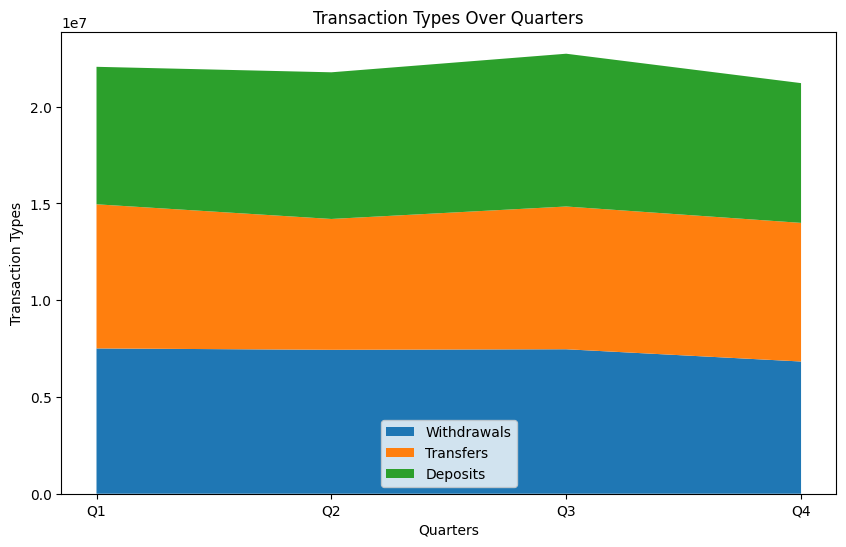

In [96]:
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
withdrawals = [quarterSum[i]['Withdrawal'] for i in range(1,5)]
transfers = [quarterSum[i]['Transfer'] for i in range(1,5)]
deposits = [quarterSum[i]['Deposit'] for i in range(1,5)]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.stackplot(quarters, withdrawals, transfers, deposits, labels = ['Withdrawals','Transfers','Deposits'])

plt.xlabel('Quarters')
plt.ylabel('Transaction Types')
plt.title('Transaction Types Over Quarters')
plt.legend()

plt.show()

In [98]:
df['Account Type'].unique()

array(['Current', 'Savings'], dtype=object)